<a href="https://colab.research.google.com/github/kifayat-irfan/AAPL-Stock-Price-Prediction-LSTM/blob/main/AAPL_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1: Data Acquisition

## 1. Install Dependencies

In [ ]:
# Install libraries
!pip install yfinance pandas matplotlib scikit-learn torch


## 2. Configuration

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Constants
TICKER_SYMBOL = 'AAPL'
START_DATE = (datetime.now() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
END_DATE = datetime.now().strftime('%Y-%m-%d')
FILE_NAME = 'AAPL_stock_data.csv'

print(f"Settings: {TICKER_SYMBOL} from {START_DATE} to {END_DATE}")


Settings: AAPL from 2021-06-30 to 2026-06-30


## 3. Download and Save Data

In [ ]:
# Download data from Yahoo Finance
df_raw = yf.download(TICKER_SYMBOL, start=START_DATE, end=END_DATE, auto_adjust=True)

# Extract only the closing price
closing_prices = df_raw[['Close']]

# Save to local CSV
closing_prices.to_csv(FILE_NAME)
print(f"Successfully saved to {FILE_NAME}")


[*********************100%***********************]  1 of 1 completed

Successfully saved to AAPL_stock_data.csv


## 4. Visualize Raw Data

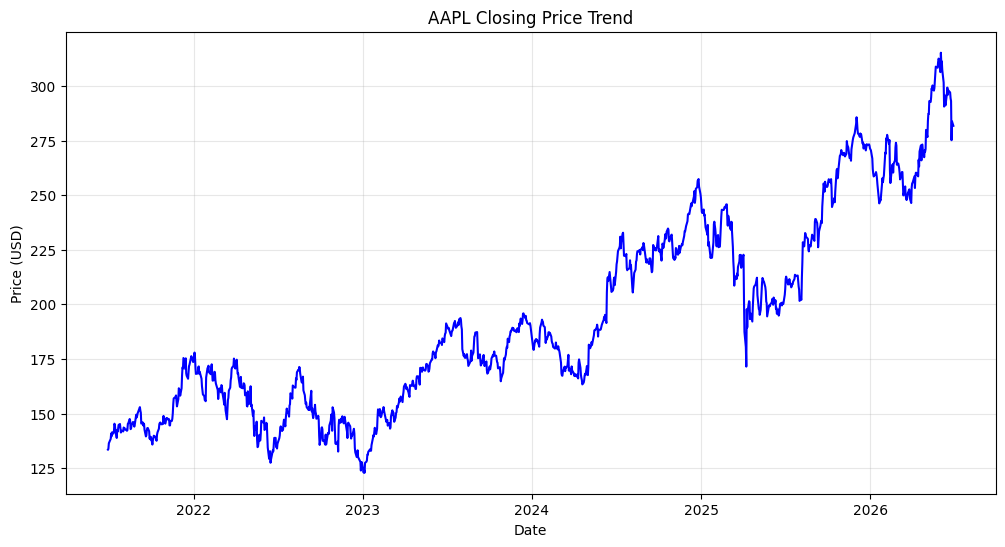

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(closing_prices.index, closing_prices['Close'], color='blue')
plt.title(f"{TICKER_SYMBOL} Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.show()


## Module 2: Data Preprocessing

## 5. Load and Clean Data

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# Load the CSV
df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)

# FIX: Remove Multi-index headers if they exist
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# FIX: Force numeric values and remove strings (like 'AAPL')
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df = df.dropna(subset=['Close'])

print("Data cleaned and header fixed.")


Data cleaned and header fixed.


/tmp/ipykernel_463/2858262144.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(FILE_NAME, index_col=0, parse_dates=True)


## 6. Data Normalization

In [ ]:
# Convert to numpy array
data_values = df[['Close']].values.astype('float32')

# Scale data between 0 and 1 for the LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

print(f"Normalization complete. Min: {scaled_data.min()}, Max: {scaled_data.max()}")


Normalization complete. Min: 0.0, Max: 0.9999999403953552


## 7. Sliding Window Function

In [ ]:
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size]) # Past 30 days
        y.append(data[i + window_size])     # Next 1 day
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
X, y = create_sequences(scaled_data, WINDOW_SIZE)
print(f"Sequences created. X shape: {X.shape}, y shape: {y.shape}")


Sequences created. X shape: (1224, 30, 1), y shape: (1224, 1)


## 8. Train-Test Split

In [ ]:
# Split into 80% Training and 20% Testing
train_size = int(len(X) * 0.8)

X_train_np, X_test_np = X[:train_size], X[train_size:]
y_train_np, y_test_np = y[:train_size], y[train_size:]

print(f"Train size: {len(X_train_np)}, Test size: {len(X_test_np)}")


Train size: 979, Test size: 245


## 9. Convert to PyTorch Tensors

In [ ]:
# Convert numpy arrays to float32 tensors
X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np)
X_test = torch.FloatTensor(X_test_np)
y_test = torch.FloatTensor(y_test_np)

print("Conversion to Tensors complete.")


Conversion to Tensors complete.


## Module 3: Advanced LSTM Model

## 10. Model Architecture

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # A simple linear layer to start. If this doesn't work, the data is the problem.
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Take the last time step output
        last_step = lstm_out[:, -1, :]
        return self.linear(last_step)

print("Robust Model Defined.")


Robust Model Defined.


## 11. DataLoaders & Optimizer

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create PyTorch Datasets
train_ds = TensorDataset(X_train, y_train)
# shuffle=True is CRITICAL to prevent the "flat line" collapse
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

model = StockLSTM().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Standard LR

print(f"DataLoader initialized. Training will now use shuffled batches on {device}.")


DataLoader initialized. Training will now use shuffled batches on cuda.


## 12. Training Loop

In [ ]:
epochs = 100
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}')

print("Training Finished!")


Epoch [10/100], Loss: 0.001063
Epoch [20/100], Loss: 0.000750
Epoch [30/100], Loss: 0.000614
Epoch [40/100], Loss: 0.000520
Epoch [50/100], Loss: 0.000418
Epoch [60/100], Loss: 0.000362
Epoch [70/100], Loss: 0.000304
Epoch [80/100], Loss: 0.000340
Epoch [90/100], Loss: 0.000282
Epoch [100/100], Loss: 0.000296
Training Finished!


## Final Evaluation

## 13. Predictions and Inverse Scaling

In [ ]:
model.eval()
with torch.no_grad():
    # Predict using test set
    predictions = model(X_test).cpu().numpy()
    actuals = y_test.cpu().numpy()

# Convert 0-1 scale back to original USD prices
predictions = scaler.inverse_transform(predictions)
actuals = scaler.inverse_transform(actuals)

print("Inverse scaling complete.")


Inverse scaling complete.


## 14. Final Result Plot

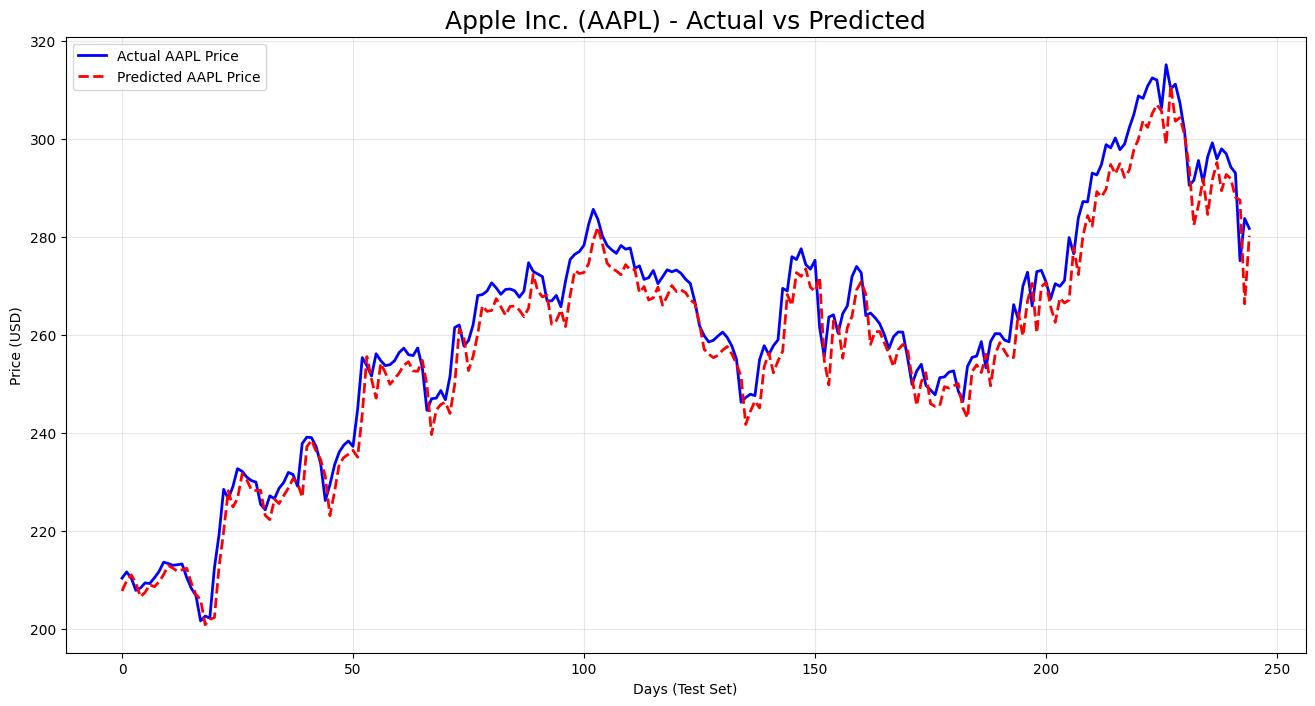

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(actuals, label='Actual AAPL Price', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted AAPL Price', color='red', linestyle='--', linewidth=2)
plt.title('Apple Inc. (AAPL) - Actual vs Predicted', fontsize=18)
plt.xlabel('Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
